# Popular Data Science Questions

## Introduction

This project aims to work out what content is 'best' to data science content to write about. That is, what do people most want to learn about in data science?

## Stack Exchange

**Data Science Stack Exchange** is a question and answer site for Data Science professionals. The questions posted should be about getting answers to specific problems rather than general discussion or debatable topics. 

The **Stack Echange** home page contains sections for, amongst other things, links to various *communities* that focus on particular topics. It shows a schedule of 'hot' question links, a list of 'Top Network Askers'.

Each post contains *tags* (categorising the content), the number of answers, when the question was asked and by who as well as the community in which the question was asked.

## Stack Exchange Data Explorer

Stack Exchange provides a public database to [query](https://data.stackexchange.com/stackoverflow/query/new) its data.

After exploring the Data Explorer, the `Posts` table has the information needed as it contains `Tags` and `ViewCount` that will be useful in the analysis.

## Getting the Data

The required data from Stack Exchange Data Explorer has been exported to a `csv` file `2019_questions.csv`.

## Exploring the Data

In [1]:
# Import modules to be used in this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import datetime as dt
%matplotlib inline

In [2]:
questions = pd.read_csv('2019_questions.csv', parse_dates=['CreationDate'])

Run `DataFrame.info()` to inspect types, column names and non-null counts...

In [3]:
questions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8839 entries, 0 to 8838
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id             8839 non-null   int64         
 1   CreationDate   8839 non-null   datetime64[ns]
 2   Score          8839 non-null   int64         
 3   ViewCount      8839 non-null   int64         
 4   Tags           8839 non-null   object        
 5   AnswerCount    8839 non-null   int64         
 6   FavoriteCount  1407 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 483.5+ KB


The only column with missing values is `FavoriteCount`. It would make sense that if there is a missing value in this column, that it hasn't been 'favourited' and therefore the missing values could be replaced with zeros.

The `FavouriteCount` column should probably be an integer rather than a float datatype.

In [4]:
questions.head()

,Id,CreationDate,Score,ViewCount,Tags,AnswerCount,FavoriteCount
0,44419,2019-01-23 09:21:13,1,21,<machine-learning><data-mining>,0,NaN
1,44420,2019-01-23 09:34:01,0,25,<machine-learning><regression><linear-regressi...,0,NaN
2,44423,2019-01-23 09:58:41,2,1651,<python><time-series><forecast><forecasting>,0,NaN
3,44427,2019-01-23 10:57:09,0,55,<machine-learning><scikit-learn><pca>,1,NaN
4,44428,2019-01-23 11:02:15,0,19,<dataset><bigdata><data><speech-to-text>,0,NaN


The `Tags` column contains strings of tags, each one surrounded by braces that would be more useful as a comma separated list of values.

## Cleaning the Data

Fill the missing values in `FavoriteCount` with 0s and convert to integer datatype.

In [5]:
questions['FavoriteCount'] = questions['FavoriteCount'].fillna(0).astype('int')

Replace '<' and '>' with empty strings and '><' with a comma in `Tags`. Then convert to a list and assign back to `Tags`.

In [6]:
questions['Tags'] = (questions['Tags'].str.replace('><', ',')
                     .str.replace('<', '')
                     .str.replace('>', '')
                     .str.split(','))

## Most Used and Most Viewed

Calculate how many times each tag was used and convert the dictionary used to collect the counts to a DataFrame to enable visualisation.

In [7]:
count_tags = {}
for tags in questions['Tags']:
    for tag in tags:
        if tag in count_tags:
            count_tags[tag] += 1
        else:
            count_tags[tag] = 1

In [8]:
count_tags = pd.DataFrame.from_dict(count_tags, orient='index')
count_tags

,0
machine-learning,2693
data-mining,217
regression,347
linear-regression,175
regularization,50
...,...
encoder,1
label-smoothing,1
label-flipping,1
3d-object-detection,1


In [9]:
count_tags.rename({0: 'Count'}, axis=1, inplace=True)

In [10]:
top_20_tags_used = count_tags.sort_values(by='Count')[-20:]
top_20_tags_used

,Count
machine-learning-model,224
statistics,234
clustering,257
predictive-modeling,265
r,268
dataset,340
regression,347
pandas,354
lstm,402
time-series,466


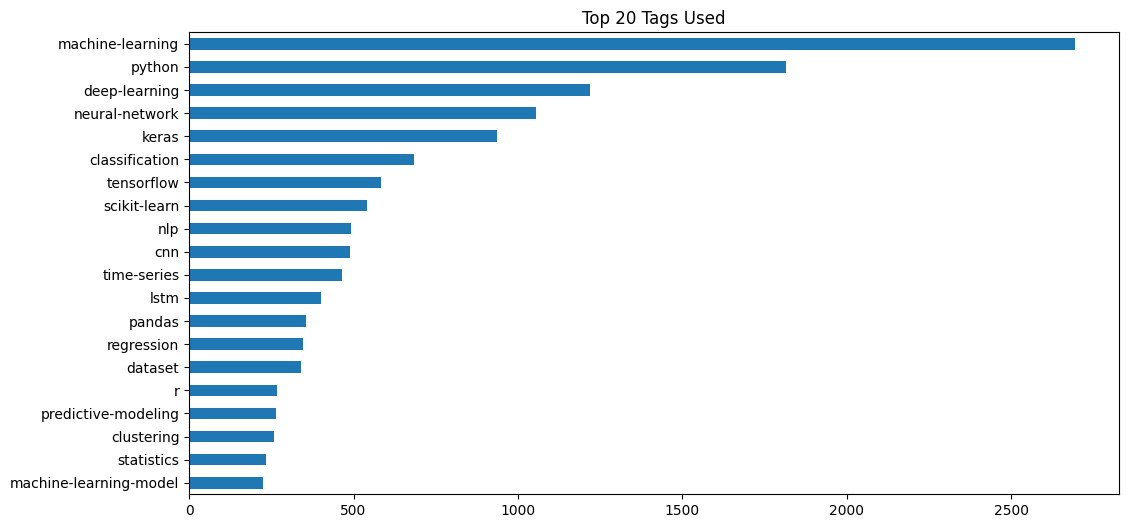

In [11]:
top_20_tags_used.plot(kind='barh',
                      figsize=(12, 6),
                      title='Top 20 Tags Used',
                      legend=False)
plt.show()

In [12]:
count_views = {}
for index, row in questions.iterrows():
    for tag in row['Tags']:
        if tag in count_views:
            count_views[tag] += row['ViewCount']
        else:
            count_views[tag] = row['ViewCount']

In [13]:
count_views = pd.DataFrame.from_dict(count_views, orient='index')

In [14]:
count_views.rename({0: 'ViewCount'}, axis=1, inplace=True)

In [15]:
top_20_viewed = count_views.sort_values(by='ViewCount')[-20:]

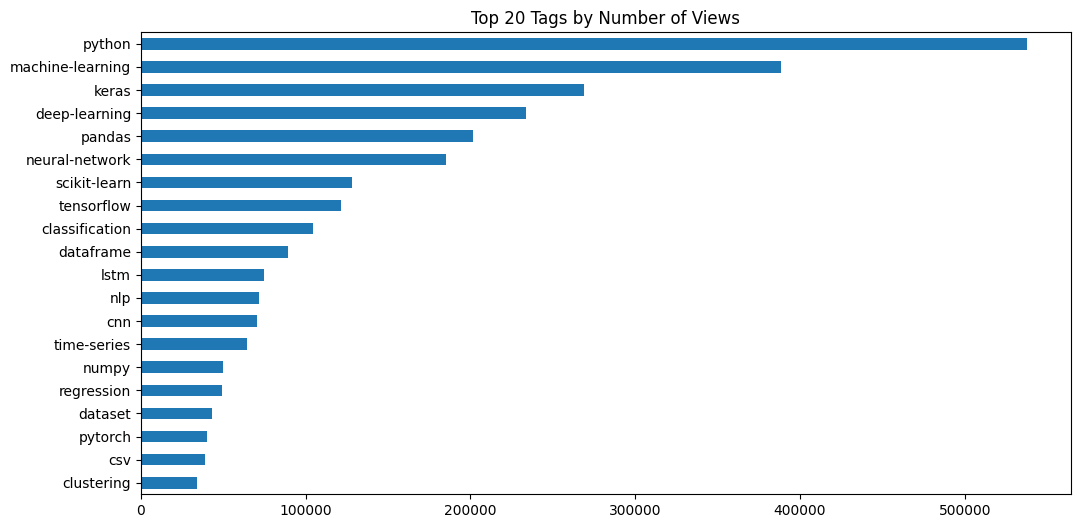

In [16]:
top_20_viewed.plot(kind='barh',
                   figsize=(12, 6),
                   title='Top 20 Tags by Number of Views',
                   legend=False)
plt.show()

From the above, most of the top tags appear in both sets of results, that is, both most frequently used and most often viewed.

## Relations Between Tags

Investigate which of the `top_20_tags_used` appear most often together.

Firstly, create a list of tags from the `top_20_tags_used` DataFrame.

In [17]:
top_tags = list(top_20_tags_used.index)

Create a new column in `questions` where the list of tags contains only those that appear in `top_20_tags_used`.

In [18]:
questions['top_20_tags'] = questions['Tags'].apply(
    lambda tags: [tag for tag in tags if tag in top_tags]
)

Convert the filtered tags to a Binary Matrix.

In [19]:
mlb = MultiLabelBinarizer()
tag_matrix = mlb.fit_transform(questions['top_20_tags'])
df_binary = pd.DataFrame(tag_matrix,
                         columns=mlb.classes_)[top_tags]

Compute the co-occurrence matrix...

In [20]:
co_occurrence = df_binary.T.dot(df_binary)
co_occurrence_df = pd.DataFrame(co_occurrence,
                                index=top_tags,
                                columns=top_tags)

Extract the top co-occurring pairs of tags...

In [21]:
mask = np.triu(np.ones(co_occurrence_df.shape), k=1).astype(bool)
co_occurrence_pairs = co_occurrence_df.where(mask).stack().sort_values(ascending=False)

top_10_pairs = co_occurrence_pairs.head(10)

In [22]:
top_10_pairs

python          machine-learning    499.0
deep-learning   machine-learning    429.0
neural-network  machine-learning    366.0
                deep-learning       305.0
keras           python              280.0
classification  machine-learning    259.0
tensorflow      keras               256.0
keras           deep-learning       247.0
pandas          python              244.0
scikit-learn    python              235.0
dtype: float64

Show the relationship between pairs of tags as a heatmap (only showing the lower triangle)...

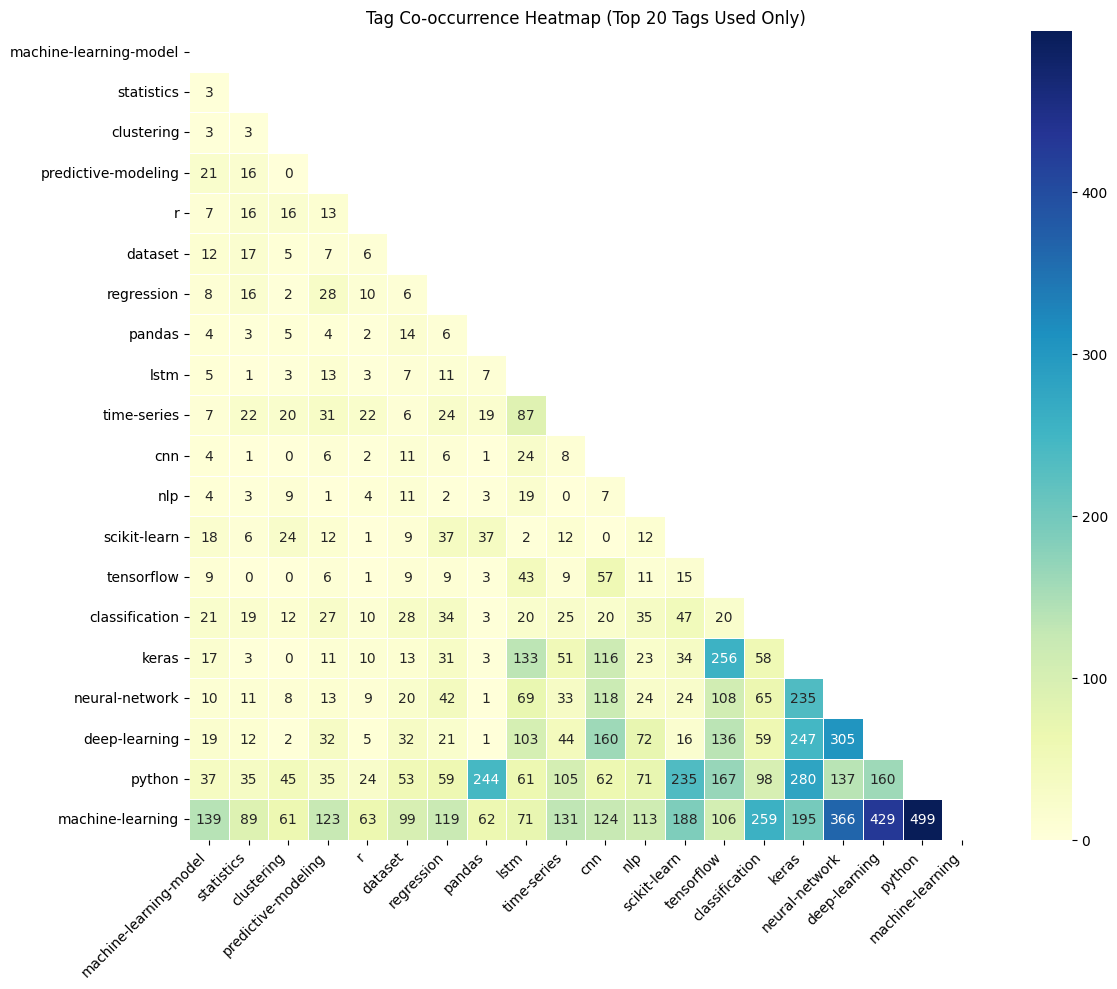

In [23]:
mask = np.triu(np.ones_like(co_occurrence_df, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_df,
            mask=mask,
            annot=True,
            fmt='d',
            cmap='YlGnBu',
            linewidth=0.5)
plt.title('Tag Co-occurrence Heatmap (Top 20 Tags Used Only)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Analysing relationships between multiple tags could be carried out with association rule mining but will not be carried out at this time.

## Enter Domain Knowledge

It looks like most of the most frequently appearing tags that appear in the same questions are all related to machine learning, be that the general 'machine-learning' and 'python' tags or the associated packages and modules used in Python to carry out machine learning analysis.

## Just a Fad?

To try to analyse the trend on questions about deep learning. This will be done by analysing `all_questions.csv` that is a schedule of all questions asked on Data Science Stack Exchange showing when the post was created and the tags associated with it.

In [24]:
all_q = pd.read_csv('all_questions.csv', parse_dates=['CreationDate'])

Convert the `Tags` column to a list of tags...

In [25]:
all_q.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21576 entries, 0 to 21575
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            21576 non-null  int64         
 1   CreationDate  21576 non-null  datetime64[ns]
 2   Tags          21576 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 505.8+ KB


In [26]:
all_q['Tags'] = (all_q['Tags'].str.replace('><', ',')
                     .str.replace('<', '')
                     .str.replace('>', '')
                     .str.split(','))

Create a List of tags that are deemed to be associated with deep learning that appear in the top 20 list of tags...

In [27]:
dl_tags = ['lstm', 'cnn', 'scikit-learn', 'tensorflow',
           'keras', 'neural-network', 'deep-learning']

Create a column in `all_q` that shows whether the defined deep learning tags appear in the post...

In [28]:
def is_deep_learning(tags):
    for tag in tags:
        if tag in dl_tags:
            return 1
    return 0

all_q['DeepLearning'] = all_q['Tags'].apply(is_deep_learning)
all_q.head()

,Id,CreationDate,Tags,DeepLearning
0,45416,2019-02-12 00:36:29,"[python, keras, tensorflow, cnn, probability]",1
1,45418,2019-02-12 00:50:39,[neural-network],1
2,45422,2019-02-12 04:40:51,"[python, ibm-watson, chatbot]",0
3,45426,2019-02-12 04:51:49,[keras],1
4,45427,2019-02-12 05:08:24,"[r, predictive-modeling, machine-learning-mode...",0


In [29]:
all_q['CreationDate'].describe()

count                            21576
mean     2018-05-09 10:31:31.242167296
min                2014-05-13 23:58:30
25%      2017-07-24 01:40:20.249999872
50%                2018-09-18 06:54:19
75%      2019-06-13 07:55:33.750000128
max                2020-01-19 03:01:03
Name: CreationDate, dtype: object

As the dataset runs up to mid January 2020, the trend shall be looked at up to the end of 2019, by quarter.

In [30]:
all_q = all_q[all_q['CreationDate'].dt.year < 2020]

In [31]:
all_q['Quarter'] = all_q['CreationDate'].dt.to_period('Q').astype(str)

The ratio between the number of deep learning questions and the total number of questions can now be calculated for each quarter.

In [32]:
quarters = all_q.groupby('Quarter').agg({'DeepLearning': ['sum', 'size']})
quarters.columns = ['DeepLearningQty', 'TotalQty']
quarters['DeepLearningProportion'] = quarters['DeepLearningQty'] / quarters['TotalQty']
quarters.reset_index(inplace=True)
quarters.head()

,Quarter,DeepLearningQty,TotalQty,DeepLearningProportion
0,2014Q2,9,157,0.057325
1,2014Q3,13,189,0.068783
2,2014Q4,21,216,0.097222
3,2015Q1,18,190,0.094737
4,2015Q2,28,284,0.098592


Show the result of this analysis in a chart showing the volume of deep learning questions (bar plot) and the change in proportion of deep learning questions over time (line plot).

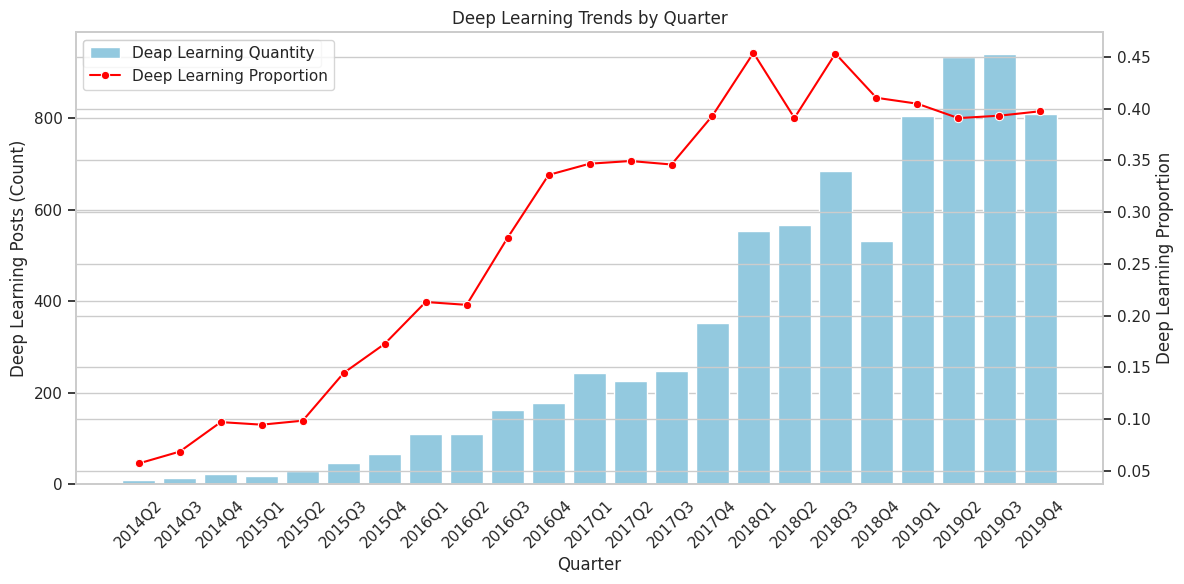

In [33]:
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
# Bar Plot to show the volume of deep learning questions
ax1 = sns.barplot(data=quarters,
                  x='Quarter',
                  y='DeepLearningQty',
                  color='skyblue',
                  label='Deap Learning Quantity')
# Twin y axis for the line plot
ax2 = ax1.twinx()
# Line Plot to show the change in proportion of deep learning questions over time
sns.lineplot(data=quarters,
             x='Quarter',
             y='DeepLearningProportion',
             color='red',
             marker='o',
             ax=ax2,
             label='Deep Learning Proportion')
ax1.set_ylabel('Deep Learning Posts (Count)')
ax2.set_ylabel('Deep Learning Proportion')
ax1.tick_params(axis='x', rotation=45)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
plt.title('Deep Learning Trends by Quarter')
plt.tight_layout()
plt.show()

The proportion and volume of questions relating to deep learning increased steadily from Quarter 2, 2014 to the back end of 2017. It then appears to have been fairly constant with a proportion of questions of between 40 and 45% which shows that proposing creation of deep learning content is feasible.